# Create a topological network from spatial data

`snkit` helps with spatial networks problems, mainly the kind of thing that comes up in data cleaning, tidying and pre-processing.

This notebook goes through a cleaning process:
- read in a set of nearly-connected points and lines
- add nodes at the line endpoints
- links the remaining points to the existing lines (if they're within a specified distance)
- give everything a unique ID
- add from/to ids to the edges

The data is output in a state ready to be used as a network graph for further analysis.

In [1]:
import geopandas
import igraph
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import networkx
import pandas
import snkit

In [2]:
data = geopandas.read_file("small-demo.geojson")
data

,geometry
0,"LINESTRING (0.00412 -0.04086, 0.00034 -0.03347..."
1,"LINESTRING (0.01768 -0.01236, 0.01768 -0.02369..."
2,"LINESTRING (0.0297 0.01888, 0.01888 0.0182, 0...."
3,POINT (0.0309 0.04429)
4,POINT (0.0309 0.03759)
5,POINT (0.02129 0.03948)
6,POINT (0.02987 -0.0218)
7,POINT (0.03759 -0.02798)
8,POINT (-0.00275 -0.02867)
9,POINT (-0.0012 -0.03811)


In [3]:
edges = data[:3]
nodes = data[3:]

In [4]:
def plot_network(n):
    df = pandas.concat([n.nodes, n.edges], axis=0, sort=False)
    ax = df.plot()
    offset = 0.001
    rounding = 3

    labelled_locations = set()

    if "id" in df.columns:
        labelled = df.dropna(subset=["id", "geometry"])
        for _, row in labelled.iterrows():
            point = row.geometry.centroid
            px = round(point.x, rounding)
            py = round(point.y, rounding)
            if (px, py) in labelled_locations:
                continue
            
            labelled_locations.add((px, py))
            ax.annotate(
                str(row["id"]),
                xy=(point.x + offset, point.y  - offset),
                fontsize=6,
                path_effects=[pe.withStroke(linewidth=2, foreground="white")]
            )

    return ax

A network consists of nodes and edges - `snkit` stores these as two separate `GeoDataFrame`s.

<Axes: >

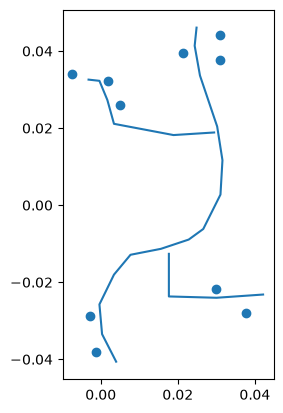

In [5]:
base_network = snkit.Network(nodes, edges)
plot_network(base_network)

Add points at the end of each line. This uses the first and last coordinate pair from each `LineString` geometry and creates a node at each point.

<Axes: >

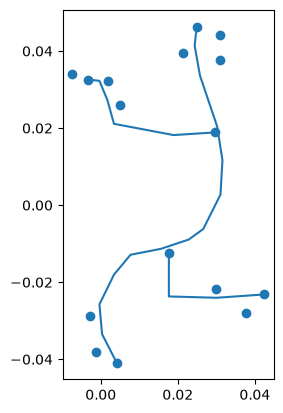

In [6]:
with_endpoints = snkit.network.add_endpoints(base_network)
plot_network(with_endpoints)

Links each point to any (all) edges within a distance threshold.

For a typical edge, this:
- finds any nodes within the given distance
- creates new straight-line edges from the edge directly to each node
- splits the original edge at each point where the new edges intersect

<Axes: >

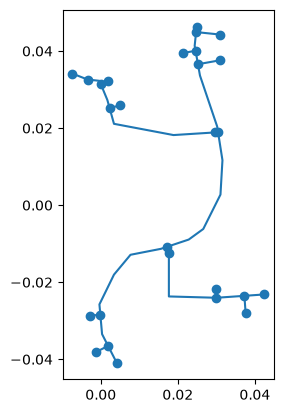

In [7]:
linked = snkit.network.link_nodes_to_edges_within(with_endpoints, 0.01)
plot_network(linked)

Linking nodes is sensitive to the distance parameter - depending on the dataset or problem, some nodes will not be connected if they are too far from the nearest line (see top right in the figure below).

<Axes: >

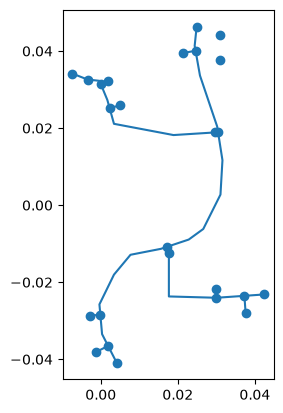

In [8]:
linked_n = snkit.network.link_nodes_to_edges_within(with_endpoints, 0.005)
plot_network(linked_n)

Add IDs to each node and edge, then add topology, recording the ids of nodes at each end of each edge. 

This is saved as `from_id` and `to_id` but `snkit` currently has no opinion about direction or ordering - from/to could easily be reversed.

<Axes: >

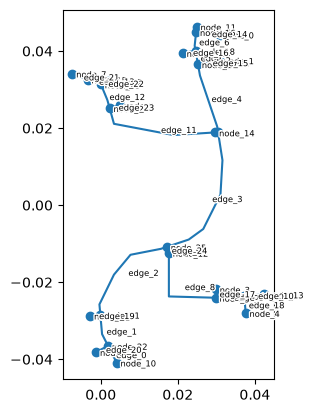

In [9]:
with_topology = snkit.network.add_topology(snkit.network.add_ids(linked))
plot_network(with_topology)

Preview data.

In [10]:
with_topology.nodes.head()

,geometry,id
0,POINT (0.0309 0.04429),node_0
1,POINT (0.0309 0.03759),node_1
2,POINT (0.02129 0.03948),node_2
3,POINT (0.02987 -0.0218),node_3
4,POINT (0.03759 -0.02798),node_4


In [11]:
with_topology.edges.head()

,geometry,id,from_id,to_id
0,"LINESTRING (0.00412 -0.04086, 0.0019 -0.03652)",edge_0,node_10,node_22
1,"LINESTRING (0.0019 -0.03652, 0.00034 -0.03347,...",edge_1,node_22,node_21
2,"LINESTRING (-0.0001 -0.02843, -0.00034 -0.0257...",edge_2,node_21,node_25
3,"LINESTRING (0.01717 -0.01081, 0.02283 -0.00893...",edge_3,node_25,node_26
4,"LINESTRING (0.03044 0.019, 0.03021 0.02043, 0....",edge_4,node_26,node_17


Save the data to a [geopackage](https://www.geopackage.org/) for later visualisation or analysis:

In [12]:
with_topology.nodes.to_file("network.gpkg", layer="nodes", driver="GPKG", index=False)
with_topology.edges.to_file("network.gpkg", layer="edges", driver="GPKG", index=False)

Convert to [`networkx.Graph`](https://networkx.org/documentation/stable/reference/classes/graph.html)

In [13]:
projected = snkit.Network(with_topology.nodes.copy(), with_topology.edges.copy())
projected.to_crs("EPSG:32631")
graph_nx = snkit.network.to_networkx(projected)

..which gives us access to a whole host of algorithms in the `networkx` library.

For example, we can find the shortest path between two nodes:

In [14]:
path_nodes = networkx.shortest_path(graph_nx, "node_0", "node_10")  # gives a list of node ids
path_edges = list(zip(path_nodes, path_nodes[1:])) # gives a list of (from_id, to_id) tuples

In [15]:
edge_dfs = []
for from_id, to_id in path_edges:
    # as our network is undirected, pull either from_id-to_id or to_id-from_id for each path edge
    ab = (projected.edges.from_id == from_id) & (projected.edges.to_id == to_id)
    ba = (projected.edges.from_id == to_id) & (projected.edges.to_id == from_id)
    df = projected.edges[ab | ba]
    edge_dfs.append(df)
path_edge_df = pandas.concat(edge_dfs)
path_edge_df

,geometry,id,from_id,to_id
14,"LINESTRING (169464.528 4901.779, 168778.568 49...",edge_14,node_0,node_16
6,"LINESTRING (168763.283 4435.231, 168737.573 45...",edge_6,node_18,node_16
5,"LINESTRING (168832.406 4049.127, 168763.283 44...",edge_5,node_17,node_18
4,"LINESTRING (169412.871 2102.683, 169387.901 22...",edge_4,node_26,node_17
3,"LINESTRING (167934.219 -1196.904, 168565.338 -...",edge_3,node_25,node_26
2,"LINESTRING (166009.82 -3146.978, 165983.257 -2...",edge_2,node_21,node_25
1,"LINESTRING (166233.446 -4042.213, 166059.72 -3...",edge_1,node_22,node_21
0,"LINESTRING (166480.501 -4521.927, 166233.446 -...",edge_0,node_10,node_22


Plot the shortest path in red over the whole network:

<Axes: >

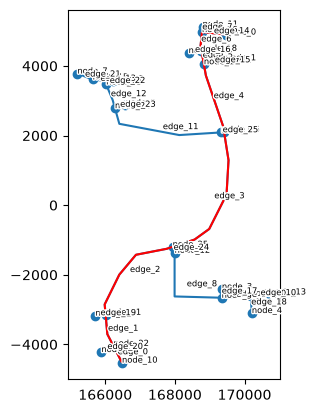

In [16]:
ax = plot_network(projected)
path_edge_df.plot(ax=ax, color='red')

Let's delete an edge so we can illustrate connected components using `igraph`. Deleting `edge_2` will split the graph so the bottom-left cluster is isolated.

In [17]:
with_topology.edges = with_topology.edges.query("id != 'edge_2'")

Convert to [`igraph.Graph`](https://python.igraph.org/en/stable/api/igraph.Graph.html), then calculate connected components using the `igraph` implementation of the algorithem, and plot using `igraph`'s helper, to see the two separated components after deleting `edge_2`

In [18]:
graph_ig = snkit.network.to_igraph(with_topology)

In [19]:
components = graph_ig.connected_components(mode="weak")

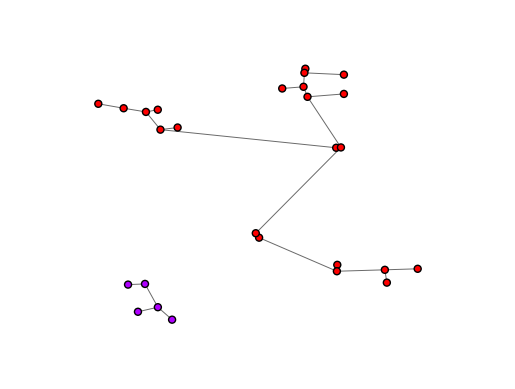

In [20]:
fig, ax = plt.subplots()
igraph.plot(
    components,
    target=ax,
    palette=igraph.RainbowPalette(),
    vertex_size=7,
    vertex_color=list(map(int, igraph.rescale(components.membership, (0, 200), clamp=True))),
    edge_width=0.7
)